# Indicators calculation

In [25]:
import geopandas as gpd
from transport_frames.indicators import *

import os
os.getcwd()

import pickle

## Initialization

In [26]:
local_crs = 32637 # Tula region crs 

The region road network graph can be obtained via ``transport_frames.graph.get_graph()``

In [27]:
with open("data/G_drive.pickle", "rb") as f:
    G_drive = pickle.load(f)

## Area indicators

Requires the ``settlement_points`` - points of interest to calculate distances from.

``distrcits_polygons`` - the polygons for data aggregation on different levels. Can be used for regional, district and settlement levels.



In [28]:
districts_polygons = gpd.read_file("data/tula_region_districts.geojson")
settlement_points = gpd.read_file("data/tula_region_towns.geojson")

 Distance (in km) to administrative center of the region.

In [29]:
region_admin_center =ox.geocode_to_gdf("N34389350",by_osmid=True) # get head town of Tula region by osmid

get_distance_to_region_admin_center(region_admin_center,settlement_points,districts_polygons,G_drive).head()

2026-04-04 23:07:28.476 | WARNING  | Removing 197 nodes from 22 smaller strongly connected components. These are subgraphs where nodes are internally reachable but isolated from the rest. Retaining only the largest strongly connected component (31927 nodes).


,name,geometry,distance_to_admin_center
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",116.5165
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",130.6290
2,Богородицкий район,"POLYGON ((37.8624 53.73471, 37.86404 53.72565,...",81.9230
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",65.4200
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",110.3645


Distance (in km) to federal roads.

In [30]:
get_distance_to_federal_roads(settlement_points,districts_polygons,G_drive).head()

2026-04-04 23:07:30.560 | WARNING  | Removing 197 nodes from 22 smaller strongly connected components. These are subgraphs where nodes are internally reachable but isolated from the rest. Retaining only the largest strongly connected component (31927 nodes).


,name,geometry,distance_to_federal_roads
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",38.1005
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",87.5390
2,Богородицкий район,"POLYGON ((37.8624 53.73471, 37.86404 53.72565,...",21.7050
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",6.6210
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",15.7180


Length of the roads in km for every district. 

In [31]:
get_road_length(G_drive, districts_polygons).head()

,name,geometry,road_length
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",785.737024
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",1214.120013
2,Богородицкий район,"POLYGON ((37.8624 53.73471, 37.86404 53.72565,...",1078.153011
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",1752.549471
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",1062.859612


Density of the roads $\mathrm{km/km^2}$.

In [32]:
get_road_density(G_drive,districts_polygons).head()

,name,geometry,density
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",0.735164
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",1.022344
2,Богородицкий район,"POLYGON ((37.8624 53.73471, 37.86404 53.72565,...",1.124087
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",1.077431
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",0.989979


Length of roads for each reg status (1 - federal, 2 - regional, 3 - local).

In [33]:
get_reg_length(G_drive,districts_polygons).head()

,name,geometry,length_reg_1,length_reg_2,length_reg_3
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",0.000000,82.519950,703.217074
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",0.000000,170.932641,1043.187372
2,Богородицкий район,"POLYGON ((37.8624 53.73471, 37.86404 53.72565,...",28.650916,183.168970,866.333125
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",148.987997,129.857315,1473.704159
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",56.833476,40.031030,965.995106


Connectivity of territories in minutes (median accessibility) based on road network graph.

In [34]:
drive_connectivity = get_connectivity(settlement_points=settlement_points,
                       area_polygons=districts_polygons,
                       local_crs=local_crs,
                       graph=G_drive)
drive_connectivity.head()

2026-04-04 23:07:37.203 | WARNING  | Removing 197 nodes from 22 smaller strongly connected components. These are subgraphs where nodes are internally reachable but isolated from the rest. Retaining only the largest strongly connected component (31927 nodes).


,name,geometry,connectivity
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",137.141621
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",158.219155
2,Богородицкий район,"POLYGON ((37.8624 53.73471, 37.86404 53.72565,...",102.153146
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",104.694100
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",111.845791


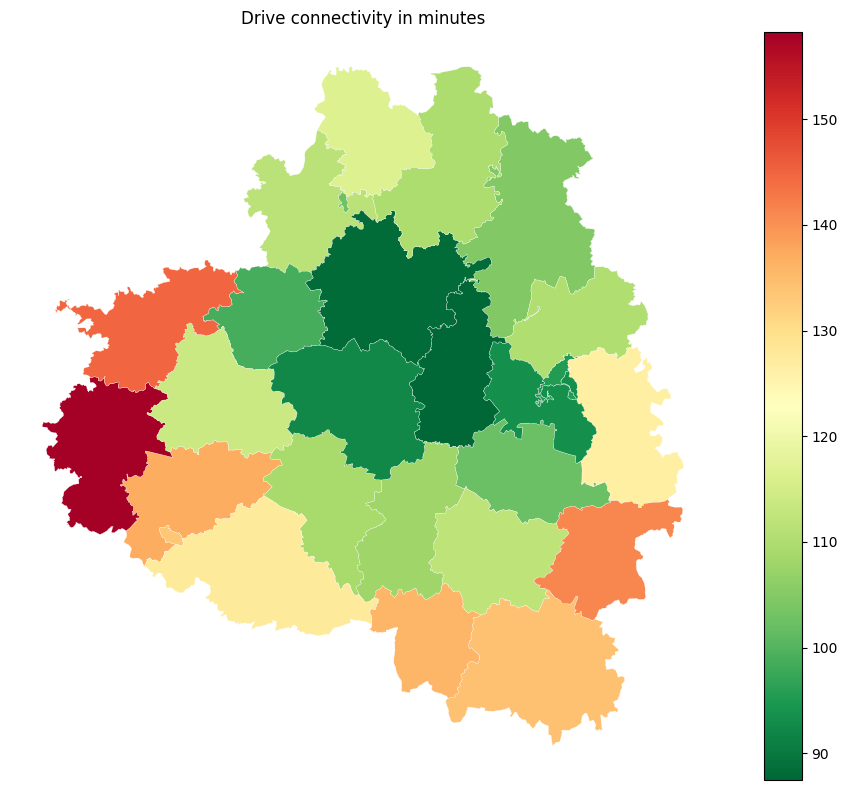

In [35]:
import pandas as pd
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(10, 8))
drive_connectivity.plot(
    column="connectivity",
    cmap="RdYlGn_r",
    legend=True,
    linewidth=0.2,
    edgecolor="white",
    ax=ax,
)

ax.set_axis_off()
ax.set_title("Drive connectivity in minutes")
plt.tight_layout()

Connectivity of territories in minutes based on intermodal network graph (public transport + walk paths).

Intermodal transport graph can be obtained using ``transport_frames.graph.get_intermodal_graph``

In [36]:
with open("data/G_inter.pickle", "rb") as f:
    G_pt = pickle.load(f)
    
intermodal_connectivity = get_connectivity(settlement_points=settlement_points,
                       area_polygons=districts_polygons,
                       local_crs=local_crs,
                       graph=G_pt)
intermodal_connectivity.head()

,name,geometry,connectivity
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",1379.251669
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",1604.354486
2,Богородицкий район,"POLYGON ((37.8624 53.73471, 37.86404 53.72565,...",907.622067
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",1105.028943
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",1103.344816


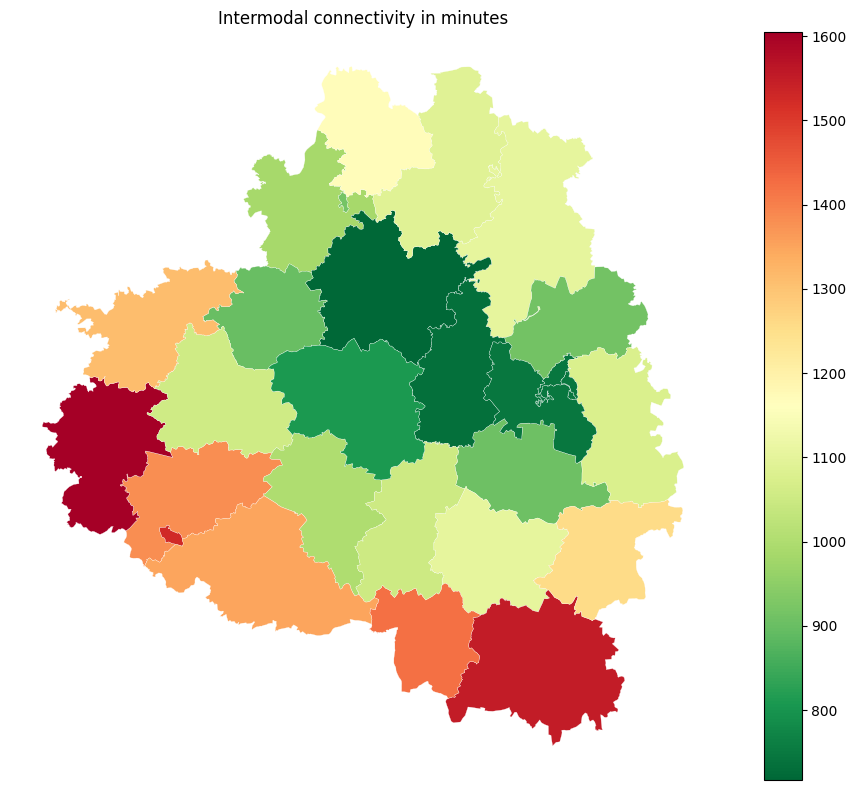

In [37]:
fig, ax = plt.subplots(figsize=(10, 8))
intermodal_connectivity.plot(
    column="connectivity",
    cmap="RdYlGn_r",
    legend=True,
    linewidth=0.2,
    edgecolor="white",
    ax=ax,
)

ax.set_axis_off()
ax.set_title("Intermodal connectivity in minutes")
plt.tight_layout()

Number of the services inside each area polygon. Example: fuel stations across region. You can pass a GeoDataFrame with any type of service (geometry type is Point).


In [38]:
fuel_stations = gpd.read_file("data/tula_region_fuel_stations.geojson")

get_service_count(districts_polygons,service=fuel_stations).head()

,name,geometry,service_number
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",1
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",3
2,Богородицкий район,"POLYGON ((37.8624 53.73471, 37.86404 53.72565,...",13
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",26
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",6


Accessibility (in minutes) of the services inside each area polygon. If the service is found inside the area, the accessibility equals to zero. Based on shortest path in the graph.

In [39]:
service_accessibility = get_service_accessibility(settlement_points, G_drive, districts_polygons,
                            service=fuel_stations)
service_accessibility.head()

2026-04-04 23:09:35.297 | WARNING  | Removing 197 nodes from 22 smaller strongly connected components. These are subgraphs where nodes are internally reachable but isolated from the rest. Retaining only the largest strongly connected component (31927 nodes).


,name,geometry,service_accessibility
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",144.500
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",164.750
2,Богородицкий район,"POLYGON ((37.8624 53.73471, 37.86404 53.72565,...",76.625
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",70.250
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",96.625


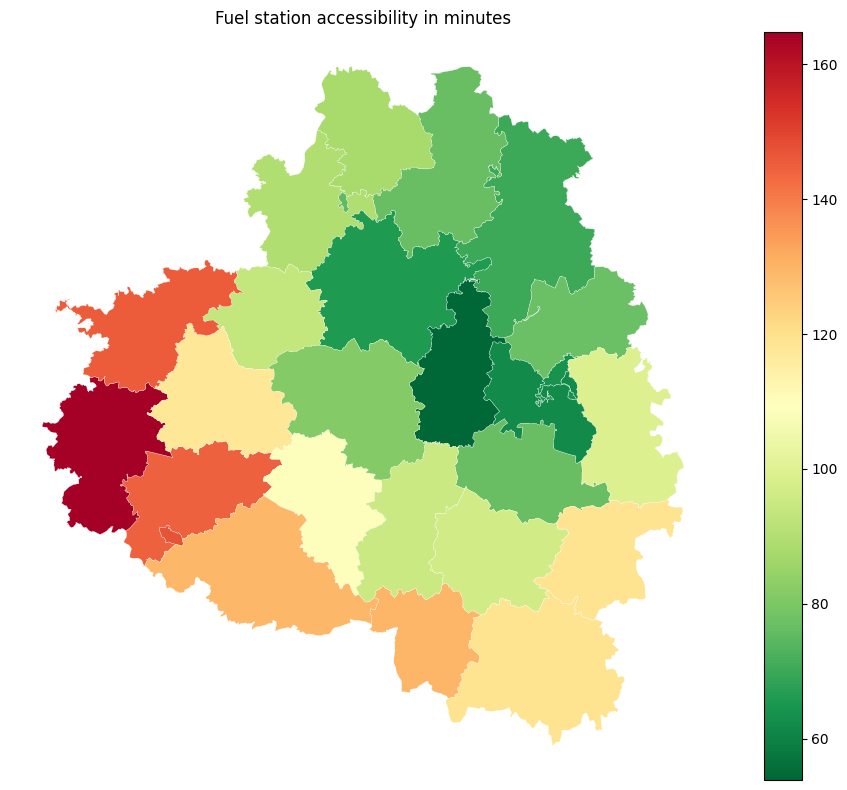

In [40]:
fig, ax = plt.subplots(figsize=(10, 8))
service_accessibility.plot(
    column="service_accessibility",
    cmap="RdYlGn_r",
    legend=True,
    linewidth=0.2,
    edgecolor="white",
    ax=ax,
)

ax.set_axis_off()
ax.set_title("Fuel station accessibility in minutes")
plt.tight_layout()

Number of bus routes intersecting the polygons.

In [41]:
get_bus_routes_num(districts_polygons, public_transport_graph = G_pt).head()

/Users/sashamorozov/Documents/Code/tf_dpo/tf/transport_frames/indicators.py:439: UserWarning: Approach is not set. Defaulting to 'primal'.
  n, e = momepy.nx_to_gdf(public_transport_graph)


,name,geometry,bus_routes_count
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",0
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",0
2,Богородицкий район,"POLYGON ((37.8624 53.73471, 37.86404 53.72565,...",1
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",0
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",0


## Territory indicators

Indicators aggregated for one territory.

<Axes: >

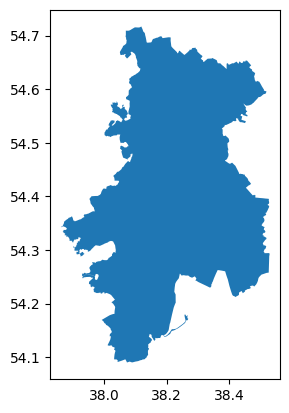

In [42]:
territory = districts_polygons.iloc[[3]]
territory.plot()

Number of the services inside territory polygon.

In [43]:
get_terr_service_count(territory,
                            service=fuel_stations,
                            local_crs=local_crs).head()

,name,geometry,service_number
3,Веневский район,"POLYGON ((37.8212 54.32909, 37.82119 54.3291, ...",26


Accessibility (min) of the services inside territory polygon. If the service is found inside the area, the accessibility equals to zero. 

Based on shortest path in the graph

In [44]:
get_terr_service_accessibility(graph=G_drive,
                                     territory_polygon=territory,
                                     service=fuel_stations)

2026-04-04 23:09:40.814 | WARNING  | Removing 197 nodes from 22 smaller strongly connected components. These are subgraphs where nodes are internally reachable but isolated from the rest. Retaining only the largest strongly connected component (31927 nodes).
/Users/sashamorozov/Documents/Code/tf_dpo/tf/.venv/lib/python3.11/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,name,geometry,service_accessibility
3,Веневский район,"POLYGON ((37.8212 54.32909, 37.82119 54.3291, ...",0.0


Density of the roads inside territory polygon $\mathrm{km/km^2}$.

In [45]:
get_road_density(G_drive, territory)

,name,geometry,density
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",1.077431


Distance from center of the polygon to the administrative center of the region

In [46]:
get_terr_distance_to_region_admin_center(region_admin_center, territory, G_drive)

2026-04-04 23:09:43.142 | WARNING  | Removing 197 nodes from 22 smaller strongly connected components. These are subgraphs where nodes are internally reachable but isolated from the rest. Retaining only the largest strongly connected component (31927 nodes).


,name,geometry,distance_to_admin_center
0,Веневский район,"POLYGON ((37.8212 54.32909, 37.82119 54.3291, ...",60.798


Shortest distance (in km) to nearest district and settlement points, which are laying in intersecting districts.

In [47]:
get_terr_nearest_centers(territory, G_drive, districts_polygons,
                               settlement_points,local_crs)

2026-04-04 23:09:44.613 | WARNING  | Removing 197 nodes from 22 smaller strongly connected components. These are subgraphs where nodes are internally reachable but isolated from the rest. Retaining only the largest strongly connected component (31927 nodes).


,name,geometry,to_nearest_center_km
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",0.968


Number of bus routes intersecting the territory

In [48]:
get_bus_routes_num(territory, public_transport_graph=G_pt).head()

/Users/sashamorozov/Documents/Code/tf_dpo/tf/transport_frames/indicators.py:439: UserWarning: Approach is not set. Defaulting to 'primal'.
  n, e = momepy.nx_to_gdf(public_transport_graph)


,name,geometry,bus_routes_count
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",0
